In [ ]:
import importlib
from RSA_nD_tuner import *
import RSA_nD_tuner
importlib.reload(RSA_nD_tuner)
from RSA_nD_tuner import *
import numpy as np
import matplotlib.pyplot as plt


(13, 10, 3)


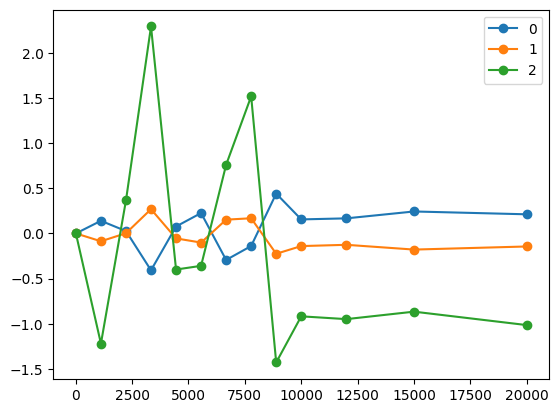

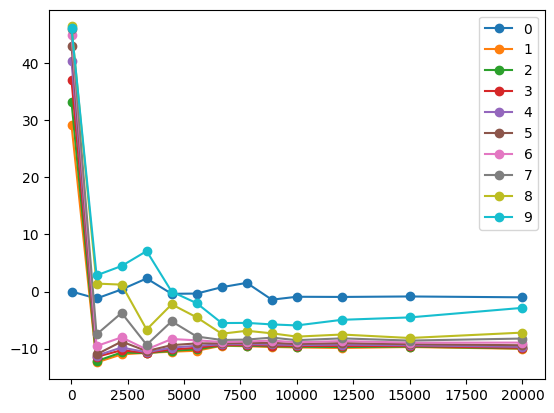

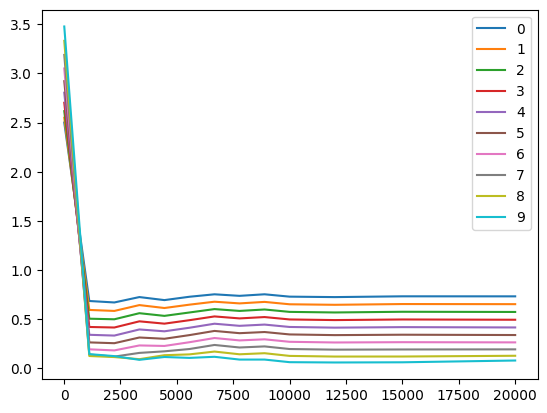

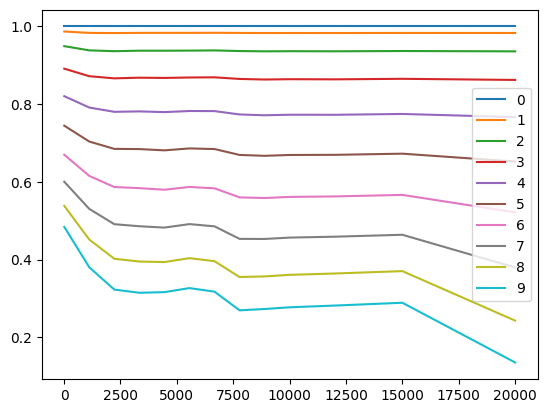

In [31]:
# Combine multiple simulated data
# Look at grad_stability/data_description.txt for description of data

plt_nm = 3
all_gradients_3 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_gradients{plt_nm}.npy')
all_loss_grid_3 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_loss_grid{plt_nm}.npy')
all_metrics_mu_3 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_mu_metrics{plt_nm}.npy', allow_pickle=True)
all_metrics_Neff_3 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Neff_metrics{plt_nm}.npy', allow_pickle=True)
Ns_3 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Ns{plt_nm}.npy', allow_pickle=True)
line_grid_3 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_line_grid{plt_nm}.npy', allow_pickle=True)

plt_nm = 2
all_gradients_2 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_gradients{plt_nm}.npy')
all_loss_grid_2 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_loss_grid{plt_nm}.npy')
all_metrics_mu_2 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_mu_metrics{plt_nm}.npy', allow_pickle=True)
all_metrics_Neff_2 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Neff_metrics{plt_nm}.npy', allow_pickle=True)
Ns_2 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Ns{plt_nm}.npy', allow_pickle=True)
line_grid_2 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_line_grid{plt_nm}.npy', allow_pickle=True)


all_gradients = np.concatenate([all_gradients_2,all_gradients_3],axis=0)
all_loss_grid = np.concatenate([all_loss_grid_2,all_loss_grid_3],axis=0)
Ns = np.concatenate([Ns_2,Ns_3],axis=0)
all_metrics_mu = np.concatenate([all_metrics_mu_2,all_metrics_mu_3])
all_metrics_Neff = np.concatenate([all_metrics_Neff_2,all_metrics_Neff_3])

line_grid = line_grid_2 # line_grid_2 == line_grid_3
print(np.shape(all_gradients))

# Plot different components of gradient for chosen point on line grid
plt.figure()
point = 0
for i in range(np.shape(all_gradients)[2]):
    plt.plot(Ns, -all_gradients[:,point,i],'-o', label=f'{i}')
plt.legend()

# Plot chosen grad component of gradient for all points on line grid
plt.figure()
grad = 2
for i in range(np.shape(all_gradients)[1]):
    plt.plot(Ns, -all_gradients[:,i,grad],'-o', label=f'{i}')
plt.legend()

# Plot loss value for all points on line grid
plt.figure()
for i in range(np.shape(all_loss_grid)[1]):
    plt.plot(Ns, all_loss_grid[:,i], label=f'{i}')
plt.legend()

# Plot metrics value for all points on line grid
plt.figure()
for i in range(np.shape(all_metrics_Neff)[1]):
    plt.plot(Ns, all_metrics_Neff[:,i], label=f'{i}')
plt.legend()



In [32]:
# # Plot only one set of simulated data

# plt_nm = 3
# all_gradients = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_gradients{plt_nm}.npy')
# all_loss_grid = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_loss_grid{plt_nm}.npy')
# all_metrics_mu = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_mu_metrics{plt_nm}.npy', allow_pickle=True)
# all_metrics_Neff = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Neff_metrics{plt_nm}.npy', allow_pickle=True)
# Ns = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Ns{plt_nm}.npy', allow_pickle=True)
# line_grid = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_line_grid{plt_nm}.npy', allow_pickle=True)

# # Plot different components of gradient for chosen point on line grid
# plt.figure()
# point = 0
# for i in range(np.shape(all_gradients)[2]):
#     plt.plot(Ns, -all_gradients[:,point,i],'-o', label=f'{i}')
# plt.legend()

# # Plot chosen grad component of gradient for all points on line grid
# plt.figure()
# grad = 2
# for i in range(np.shape(all_gradients)[1]):
#     plt.plot(Ns, -all_gradients[:,i,grad],'-o', label=f'{i}')
# plt.legend()

# # Plot loss value for all points on line grid
# plt.figure()
# for i in range(np.shape(all_loss_grid)[1]):
#     plt.plot(Ns, all_loss_grid[:,i], label=f'{i}')
# plt.legend()

# # Plot metrics value for all points on line grid
# plt.figure()
# for i in range(np.shape(all_metrics_Neff)[1]):
#     plt.plot(Ns, all_metrics_Neff[:,i], label=f'{i}')
# plt.legend()



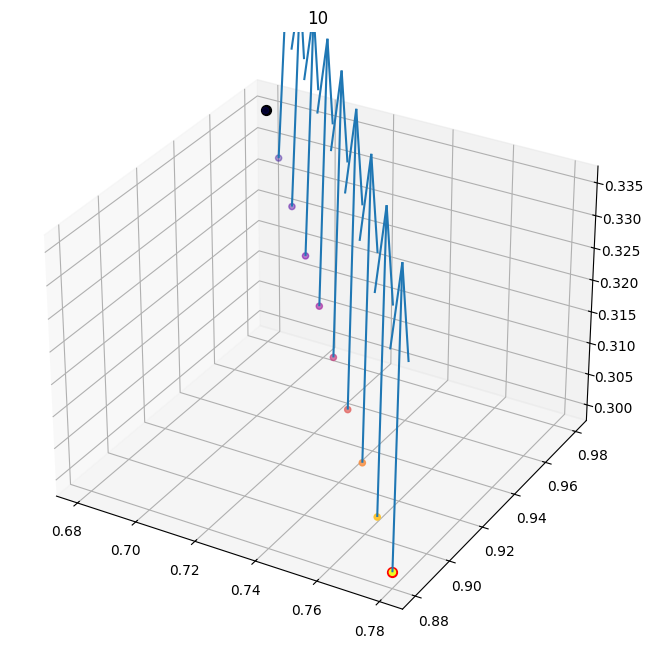

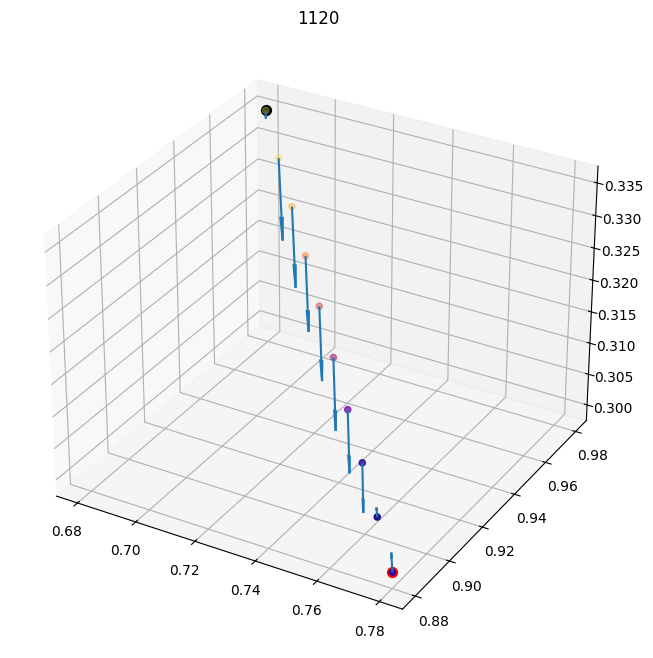

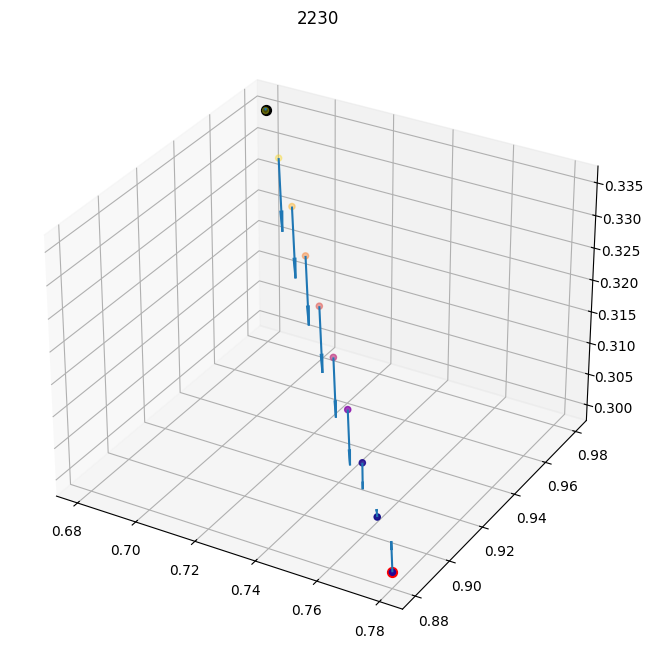

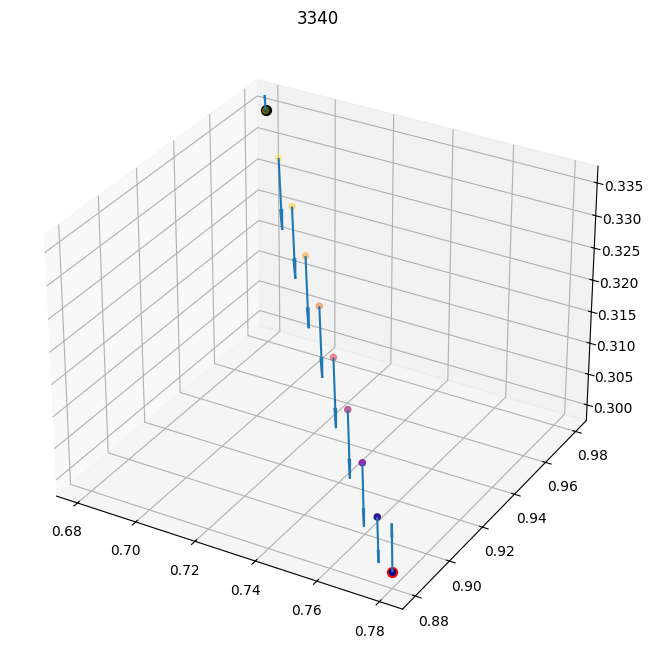

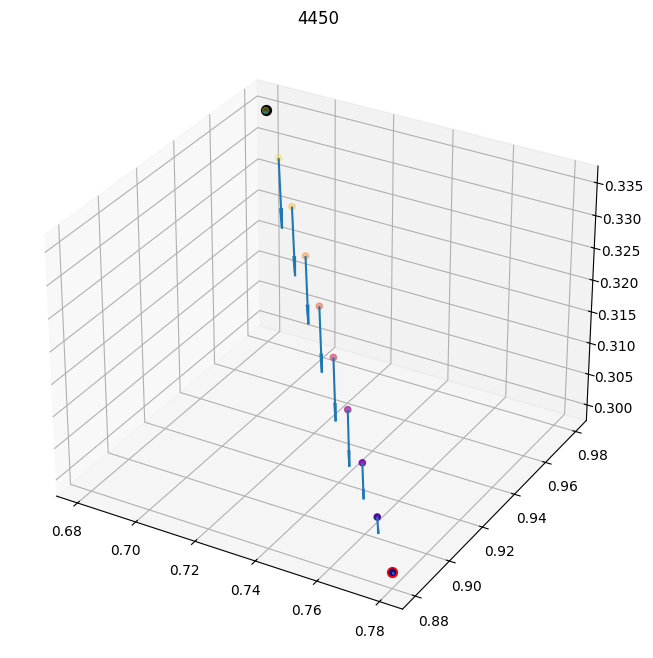

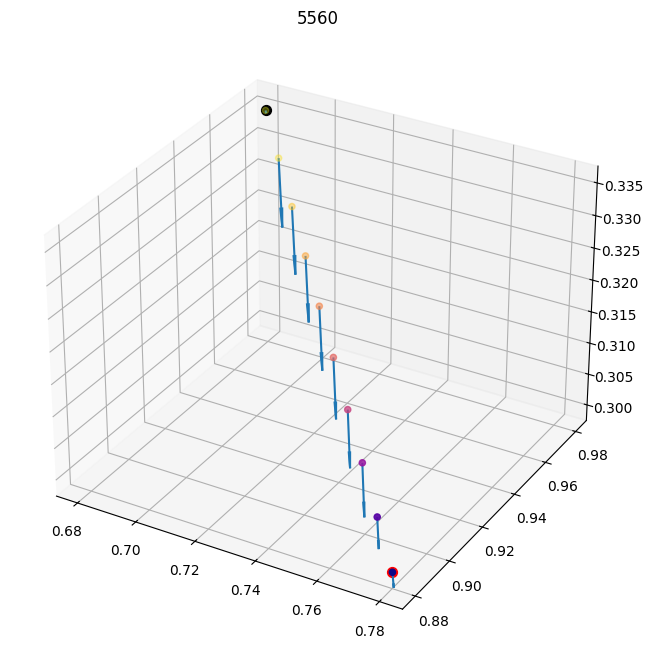

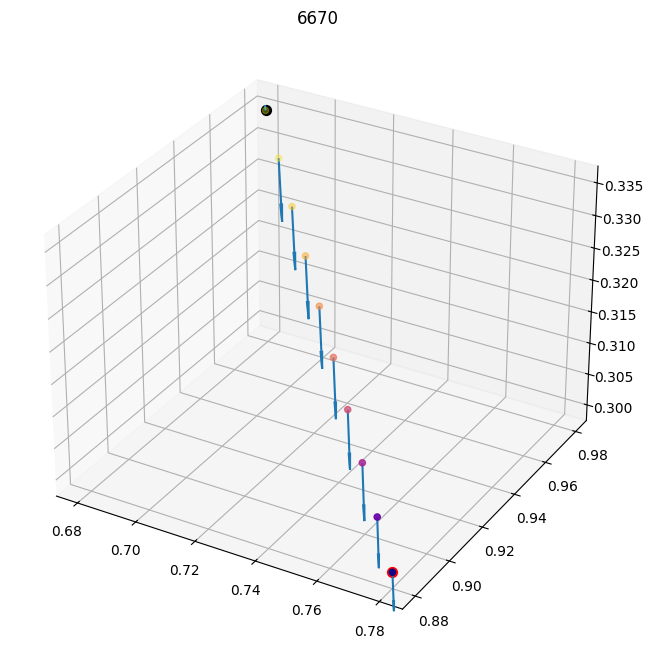

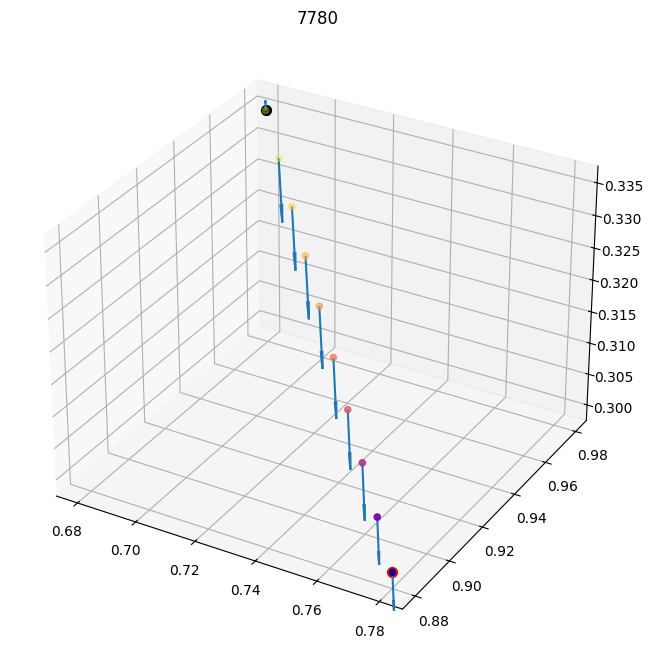

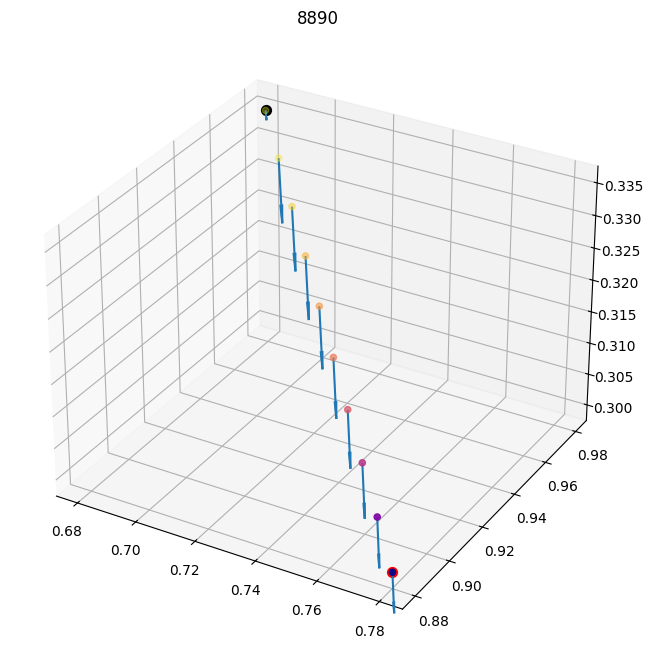

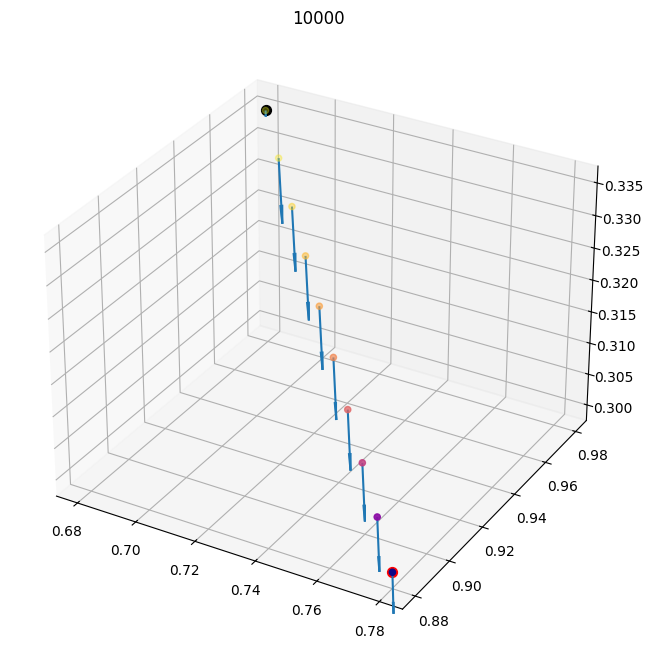

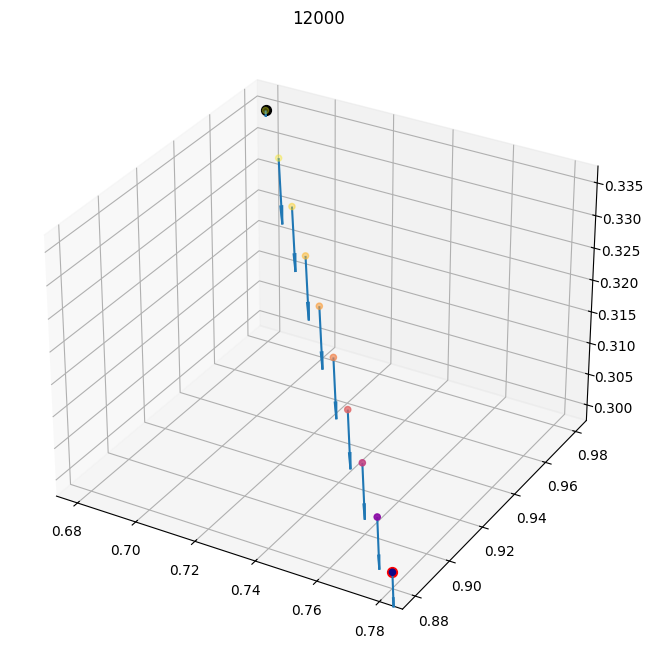

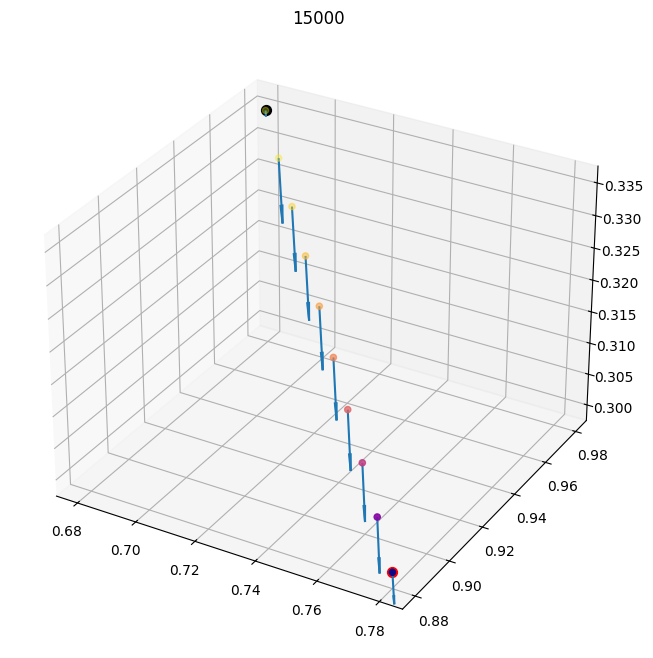

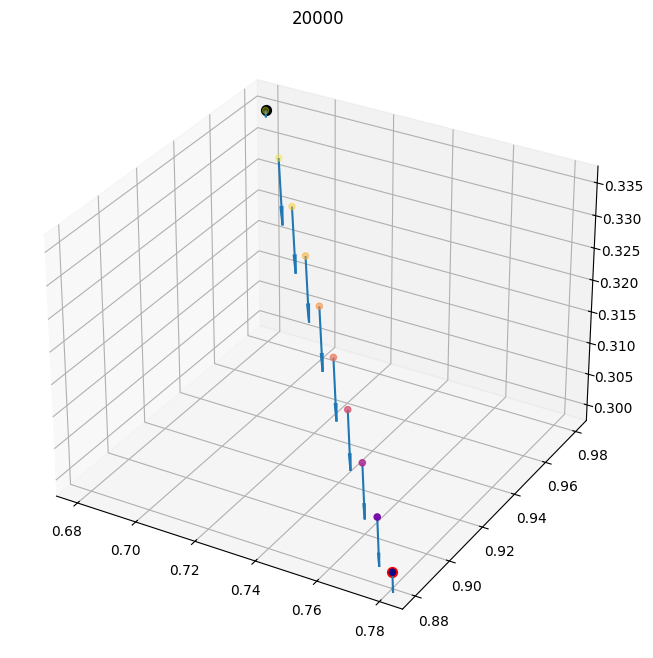

In [33]:
# Plot gradients for points on line_grid in 3D

a_b_c = line_grid

for ind, N in enumerate(Ns):
    fig = plt.figure(figsize=(10, 8))

    a_b_gradients = all_gradients[ind]
    loss_grid = all_loss_grid[ind]


    ax = fig.add_subplot(111, projection='3d')

    ad = a_b_c[:,0]
    bd = a_b_c[:,1]
    sig = a_b_c[:,2]

    g1,g2,g3 =  -a_b_gradients[:,0], -a_b_gradients[:,1], -a_b_gradients[:,2],
    scale = 10e2
    ax.quiver(ad,bd,sig,g1/scale,g2/scale,g3/scale)
    # sc = ax.scatter(ad, bd, sig, c=magnitudes, cmap='plasma', s=20)  # 's' is size, 'c' is color
    sc = ax.scatter(ad, bd, sig, c=np.log10((loss_grid)), cmap='plasma', s=20)  # 's' is size, 'c' is color
    ax.scatter(0.68,0.98,0.335, label = 'base', c= 'black', s=50)
    ax.scatter(0.78,0.88,0.300, label = 'target', c='red', s=50)
    ax.set_title(f'{N}')